In [1]:
# Setup make sure to run below:
#!pip install dimod
#!pip install dwave-ocean-sdk

import numpy as np
import pandas as pd
import networkx as nx
import yfinance as yf
import matplotlib.pyplot as plt

from tqdm import tqdm
from matplotlib import colormaps

import dimod
from dwave.cloud import Client
from dwave.system.samplers import DWaveSampler
from dwave.system.composites import EmbeddingComposite

In [2]:
endpoint = "https://cloud.dwavesys.com/sapi"
token = "ttYi-e51121f5f637eda79b9c88daffa50c66b7f08d10"

client = Client.from_config(token="ttYi-e51121f5f637eda79b9c88daffa50c66b7f08d10")
solvers = client.get_solvers()
for s in solvers:
    print(s.name)

hybrid_binary_quadratic_model_version2p
hybrid_discrete_quadratic_model_version1p
Advantage_system4.1
hybrid_constrained_quadratic_model_version1p
Advantage_system6.4
hybrid_nonlinear_program_version1p
Advantage2_system1


In [3]:
solver = "Advantage_system4.1"

Define the constants in this program

In [4]:
num_partitions = 3
gamma=8.0
gamma=8.0
beta=1.0
beta=1.0

This function calculates the modularity matrix which is given as:

$$B = A - \frac{g g^T}{2m}$$

where $A$ is the adjacency matrix of the graph, $g$ is the degree vector whose entries are $g_i = \sum_j A_{ij}$, and $m$ is the total number of edges in the graph, so that $2m = \sum_i g_i$.

In [5]:
def modularityMatrix(G):
    A = nx.to_numpy_array(G, weight="weight", dtype=float)
    g = A.sum(axis=1)
    m = g.sum() / 2.0
    B = A - np.outer(g, g) / (2.0 * m)
    return B, A, g, m

The QUBO matrix for community detection is given by the formula:

$$x^T Q x = \beta \sum_{c=1}^{k} x_c^T B x_c - \gamma \sum_{i=1}^{n} \left( \sum_{c=1}^{k} x_{i,c} - 1 \right)^2$$


In [6]:
def buildQubo(B, k, gamma, beta):
    n = B.shape[0]
    N = n * k
    Q = np.zeros((N, N), dtype=float)

    for c in range(k):
        sl = slice(c * n, (c + 1) * n)
        Q[sl, sl] += beta * B

    for i in range(n):
        idxs = [c * n + i for c in range(k)]

        for idx in idxs:
            Q[idx, idx] += -gamma

        for a in range(k):
            for b in range(a + 1, k):
                ia, ib = idxs[a], idxs[b]
                Q[ia, ib] += gamma
                Q[ib, ia] += gamma

    return Q

This function simply draws a NetworkX Graph:

In [7]:
def drawGraph(Graph, name, labels=None, showEdgeWeights=False):
    pos = nx.spring_layout(Graph, seed=7)
    cmap = colormaps["tab10"]

    node_colors = "lightblue" if labels is None else [cmap(int(c) % 10) for c in labels]

    plt.figure(figsize=(8, 6))

    if showEdgeWeights:
        edges = list(Graph.edges(data=True))
        weights = np.array([d.get("weight", 0.0) for _, _, d in edges], dtype=float)
        if len(weights) > 0 and weights.max() != weights.min():
            norm_weights = (weights - weights.min()) / (weights.max() - weights.min())
        else:
            norm_weights = np.ones_like(weights) * 0.5

        nx.draw_networkx(
            Graph,
            pos=pos,
            node_color=node_colors,
            with_labels=True,
            node_size=500,
            font_size=9,
            edge_color=norm_weights,
            edge_cmap=plt.cm.Greys,
            width=2,
        )
    else:
        nx.draw_networkx(
            Graph,
            pos=pos,
            node_color=node_colors,
            with_labels=True,
            node_size=500,
            font_size=9,
            edge_color="gray",
        )

    plt.title("Graph")
    plt.axis("off")
    plt.savefig(name, dpi=300)
    plt.show()

This code builds a NetworkX graph of how 20 stocks move with each other using their historical return covariance.

/tmp/ipykernel_8113/1859890244.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  closing_prices = yf.download(assets, start="2020-01-01")["Close"]
[*********************100%***********************]  20 of 20 completed
/tmp/ipykernel_8113/1859890244.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = closing_prices.pct_change().dropna()


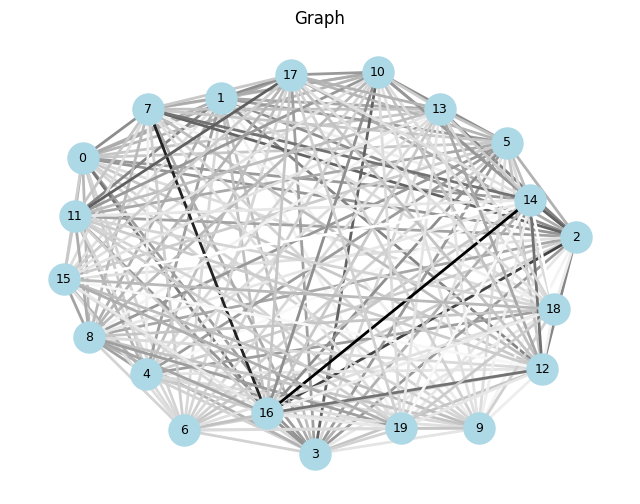

In [25]:
assets = ["AAPL", "MSFT", "GOOGL", "AMZN", "FB", "TSLA", "NVDA", "JPM", "V", "JNJ",
          "WMT", "PG", "MA", "DIS", "HD", "BAC", "VZ", "ADBE", "CMCSA", "NFLX"]

closing_prices = yf.download(assets, start="2020-01-01")["Close"]
daily_returns = closing_prices.pct_change().dropna()

covariance_matrix = daily_returns.cov().copy()
np.fill_diagonal(covariance_matrix.values, 0)

returns = daily_returns.mean() * 252

Graph = nx.from_numpy_array(covariance_matrix.to_numpy())
drawGraph(Graph=Graph, name="fig1.png", showEdgeWeights=True)

This code takes the graph and using the community detection algorithm developes a QUBO matrix `Q_communities` that will split it into `num_partitions` communities.

In [26]:
B, _, _, _ = modularityMatrix(G=Graph)
Q_communities = buildQubo(B, k=num_partitions, gamma=gamma, beta=beta)

This function calls Dwave and uses a sampler to solve a specified QUBO matrix.

In [27]:
def solve_qubo(Q, num_reads=3000, num_repeats=1):
    n = Q.shape[0]

    Q_dict = {}
    for i in range(n):
        for j in range(i, n):
            if Q[i, j] != 0:
                Q_dict[(i, j)] = float(Q[i, j])

    bqm = dimod.BinaryQuadraticModel.from_qubo(Q_dict)
    sampler = EmbeddingComposite(DWaveSampler(endpoint=endpoint, token=token, solver=solver))

    all_sets = []

    for i in tqdm(range(num_repeats)):
        ss = sampler.sample(bqm, num_reads=num_reads)
        all_sets.append(ss)

    sampleset = dimod.concatenate(all_sets)
    lowest = sampleset.lowest(rtol=0, atol=0).aggregate()

    best = max(lowest.data(["sample", "energy", "num_occurrences"]),
              key=lambda row: row.num_occurrences)

    best_sample = best.sample
    best_energy = best.energy

    print(f"Number of minima: {len(lowest)}")

    x = np.array([best_sample[i] for i in range(n)], dtype=int)

    return x, best_energy, sampleset

This code solves the `Q_communities` with the quantum annealer.  

In [28]:
best_sample_communities, _, _ = solve_qubo(Q=Q_communities, num_repeats=1)

100%|██████████| 1/1 [00:04<00:00,  4.14s/it]


Number of minima: 1


This function decodes the One Hot encoding scheme.

In [29]:
def decodeOneHot(x, n, k):
    labels = np.zeros(n, dtype=int)
    for i in range(n):
        vals = np.array([x[c * n + i] for c in range(k)])
        labels[i] = int(np.argmax(vals))
    return labels

This section decodes the one hot encoding scheme from the Dwave output and returns the partitions as a 2D array.

In [30]:
communities = decodeOneHot(n=len(assets), k=num_partitions, x=best_sample_communities)

comms = {}
nodes = list(Graph.nodes())
for node, c in zip(nodes, communities):
    comms.setdefault(int(c), set()).add(node)

partitions = [group for group in comms.values() if group]

Plots the communities:

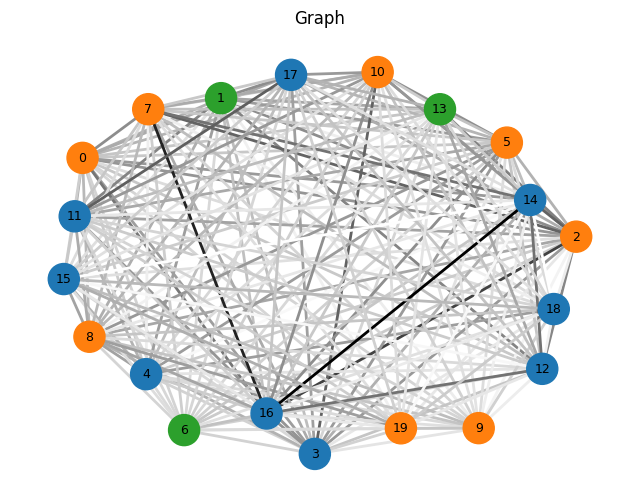

In [31]:
drawGraph(Graph=Graph, name="fig2.png", labels=communities, showEdgeWeights=True)

This section takes a collection of stock groups, computes a single average return for each group as `group_average_returns`, builds a daily return time series for each group as `group_daily_returns` and then computes the covariance matrix between the groups as `partition_covariance_matrix`

In [32]:
group_average_returns = {}
group_daily_returns = np.zeros((len(daily_returns), num_partitions))

for group_index, asset_group in enumerate(partitions):
    asset_group = list(asset_group)

    average_asset_returns = [returns.iloc[asset] for asset in asset_group]
    group_average_returns[group_index] = np.mean(average_asset_returns)

    mean_daily_return_series = daily_returns.iloc[:, asset_group].mean(axis=1)
    group_daily_returns[:, group_index] = mean_daily_return_series.to_numpy()

partition_covariance_matrix = np.cov(group_daily_returns, rowvar=False)

This generates the QUBO matrix for the asset allocation algorithm. It takes in a $1\times n$ vector `mu` and a $n\times n$ matrix `C` as the two inputs.

In [33]:
def generate_qubo_matrix(n, mu, C, p=0.1, lambda_3=10):
    size = 6 * n
    Q = np.zeros((size, size))

    for u in range(size):
        for v in range(size):
            i = u // 6
            a = (u % 6) + 1

            j = v // 6
            b = (v % 6) + 1

            if u == v:
                term1 = (2 ** (-2 * a)) * (mu[i]**2 + p**(-2) + lambda_3 * C[i, i])
                term2 = 2 * (2 ** (-a)) * (p * mu[i] + p**(-2))
                Q[u, u] = term1 - term2
            else:
                Q[u, v] = (2 ** (-a - b)) * (mu[i] * mu[j] + p**(-2) + lambda_3 * C[i, j])

    return Q

This section computes the QUBO matrix for the communities of assets, sends it to the Dwave aneeler and gets the best sample as `best_sample_upper`.

In [34]:
Q_upper = generate_qubo_matrix(n=num_partitions, mu=group_average_returns, C=partition_covariance_matrix)
best_sample_upper, _, _ = solve_qubo(Q=Q_upper)

100%|██████████| 1/1 [00:00<00:00,  2.72it/s]


Number of minima: 1


This code convertes the a binary array of `split` chunks and converts each to a float and then outputs the resulting $1\times \text{split}$ array

`[0, 1, 1, ...]` → $0\cdot 2^{-1} + 1\cdot 2^{-2} + 1\cdot 2^{-3} + \cdots$

In [35]:
def binaryToFloat(bits, split):
    chunk_size = len(bits) // split
    decimals = []

    for i in range(split):
        chunk = bits[i * chunk_size : (i + 1) * chunk_size]
        value = sum(bit * 2**-j for j, bit in enumerate(chunk, 1))
        decimals.append(value)

    return decimals

For the communities of assets it calculate the normalized allocations as the array `upper_allocations`.

In [36]:
upper_allocations = binaryToFloat(bits=best_sample_upper, split=num_partitions)

For each community we calculate the normalzied allocations of assets and store all in the 2D array `lower_allocations`.

In [37]:
lower_allocations = []

for i, cluster in enumerate(partitions):
    cluster = list(cluster)

    cluster_returns = [returns.iloc[asset] for asset in cluster]
    cluster_covariance = covariance_matrix.iloc[cluster, cluster].to_numpy()

    cluster_qubo = generate_qubo_matrix(
        n=len(cluster),
        mu=cluster_returns,
        C=cluster_covariance
    )

    best_sample_lower, _, _ = solve_qubo(Q=cluster_qubo)
    lower_allocations.append(binaryToFloat(bits=best_sample_lower, split=len(cluster)))

100%|██████████| 1/1 [00:12<00:00, 12.57s/it]


Number of minima: 1


100%|██████████| 1/1 [00:00<00:00,  2.69it/s]


Number of minima: 1


100%|██████████| 1/1 [00:24<00:00, 24.36s/it]


Number of minima: 1


Plot the assets and their allocations

In [38]:
allocations = np.array([x * y for x, group in zip(upper_allocations, lower_allocations) for y in group])
allocations /= sum(allocations)
for asset, allocation in zip(assets, allocations):
    print(f"{asset}: {allocation}")

AAPL: 0.009587431186985835
MSFT: 0.07286447702109235
GOOGL: 0.007669944949588669
AMZN: 0.0038349724747943344
FB: 0.03259726603575184
TSLA: 0.0038349724747943344
NVDA: 0.057524587121915015
JPM: 0.036432238510546174
V: 0.05566895527927259
JNJ: 0.057524587121915015
WMT: 0.11690480608647244
PG: 0.21822230469474857
MA: 0.07014288365188347
DIS: 0.13249211356466878
HD: 0.011690480608647245
BAC: 0.02338096121729449
VZ: 0.035071441825941733
ADBE: 0.02338096121729449
CMCSA: 0.02727778808684357
NFLX: 0.0038968268695490815


We now can compaire this result to running dynamic asset allocaiton without placing them into groups.